<div class='alert alert-block alert-info"'>
<h1> An sdg4varselect example :</h1>

<h4> Estimation in an Mixed-effect models </h4>

In [1]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

sdgplt.FIGSIZE = 10

### Model Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [2]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import AbstractMixedEffectsModel as AMEM


class LogisticMixedEffectsModel(AMEM):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, **kwargs):
        super().__init__(
            N=N,
            J=J,
            me_name=["phi1"],  # , "phi2"],
            **kwargs,
        )

        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                asymptotic=pc.RealPositive(scale=100),
            ),
            inflexion=pc.Real(loc=100, scale=100),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=1, scale=(200)),  # (200,200)
            var_residual=pc.RealPositive(scale=100),
        )

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        # phi2: jnp.ndarray,  # shape = (N,) [:,None]
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = asymptotic
        phi2 = inflexion
        """

        # out = phi1[:, None] / (1 + jnp.exp(-(times - phi2[:, None]) / params.tau))
        out = phi1[:, None] / (1 + jnp.exp(-(times - params.inflexion) / params.tau))
        assert out.shape == times.shape
        return out

    # ============================================================== #

    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
        ) = jrd.split(prngkey, num=2)

        # === nlmem_simulation() === #
        time = jnp.linspace(100, 1500, self.J)
        time = jnp.tile(time, (self.N, 1))
        time += 10 * jrd.uniform(prngkey_time, minval=-2, maxval=2, shape=time.shape)

        obs, sim = AMEM.sample(self, params_star, prngkey_mem, mem_obs_time=time)

        return {"mem_obs_time": time} | obs, sim

### Data Generation
Then we can generate a data set with $N=1000$ individuals and $J=20$ observation time per individuals

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


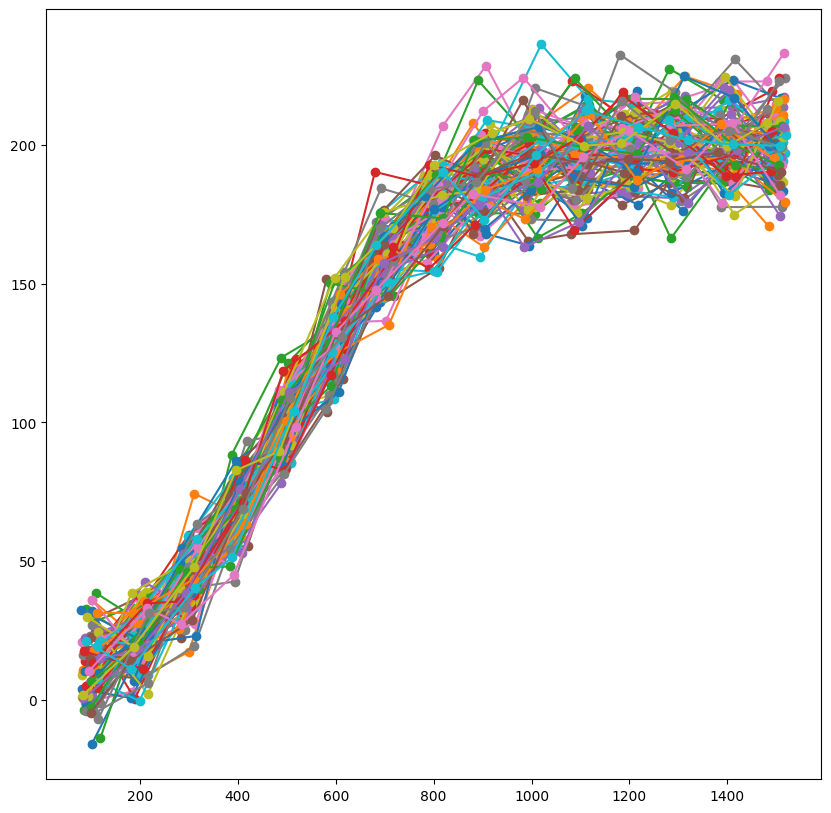

In [3]:
myModel = LogisticMixedEffectsModel(N=100, J=15)

p_star = myModel.new_params(
    mean_latent={"asymptotic": 200},  # , "inflexion": 500},
    inflexion=500,
    tau=150,
    cov_latent=jnp.diag(jnp.array([40])),  # , 100])),
    var_residual=100,
)

myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0))

fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
_ = ax.plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

# Estimation example

Let's do an estimation of the parameter with the SGD-FIM algorithm

first we need to intiate the algorithm with accurate step size.

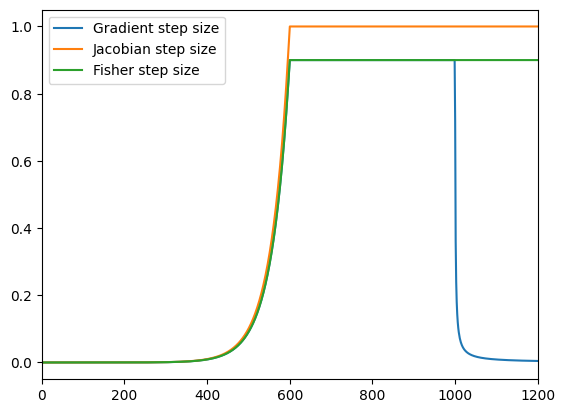

In [4]:
from sdg4varselect.outputs import GDResults, MultiRunRes
from sdg4varselect.algo import SGD_FIM, get_GDFIM_settings
from sdg4varselect.learning_rate import create_multi_step_size

algo_settings = get_GDFIM_settings(preheating=600, heating=1000, learning_rate=1e-6)
step_sizes = create_multi_step_size(list(algo_settings))
labels = ["Gradient step size", "Jacobian step size", "Fisher step size"]
[lr.plot(label=labels[i]) for i, lr in enumerate(step_sizes)]
sdgplt.plt.legend()
_ = sdgplt.plt.xlim(0, 1200)

We define a function that make one estimation run. we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [5]:
def one_estim(prngkey, model, data, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SGD_FIM(prngkey_estim, 10000, algo_settings)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"phi1": 5})  # , "phi2": 20})

    algo.latent_variables["phi1"].adaptative_sd = True
    # algo.latent_variables["phi2"].adaptative_sd = True
    # ==================== END configuration ==================== #
    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=save_all)

    # for var in algo.latent_variables.values():
    #     sdgplt.plot(var)

    return res  # , algo

Now we perform severals estimations : 

In [12]:
multi_estim = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(20)]
)

We can obtain the calculation time

In [13]:
print(multi_estim.chrono)

0:00:06.922110


And plot the results

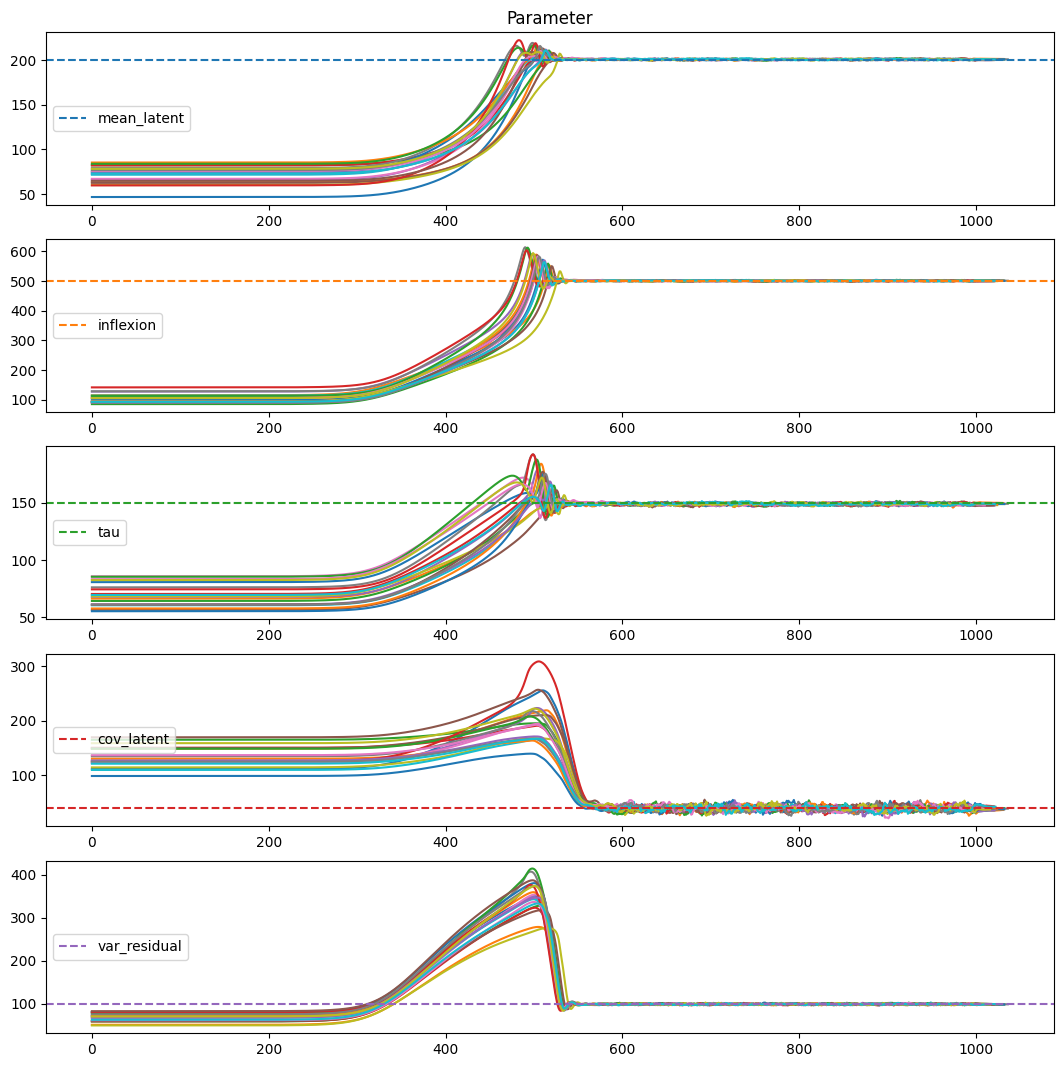

In [14]:
# === PLOT === #
sdgplt.FIGSIZE = 13

fig, axs = sdgplt.plot(
    multi_estim,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
)
# multi_estim.make_it_lighter()

In [15]:
import pandas as pd

rmse = jnp.sqrt(
    ((jnp.array(multi_estim.last_theta) - myModel.hstack_params(p_star)) ** 2).mean(
        axis=0
    )
)
pd.DataFrame(
    jnp.array(
        [
            rmse,
            jnp.array(multi_estim.last_theta).mean(axis=0),
            myModel.hstack_params(p_star),
            rmse / jnp.abs(myModel.hstack_params(p_star)),
        ]
    ).T,
    columns=["rmse", "value", "real value", "rrmse"],
    index=myModel.params_names,
).style.format(
    {
        "rmse": "{:.4f}".format,
        "value": "{:.4f}".format,
        "real value": "{:.3f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,rmse,value,real value,rrmse
mean_latent,0.9244,200.8595,200.000,0.5%
inflexion,0.7951,500.3255,500.000,0.2%
tau,1.3453,148.7990,150.000,0.9%
cov_latent,3.3977,38.6198,40.000,8.5%
var_residual,1.1207,98.9693,100.000,1.1%


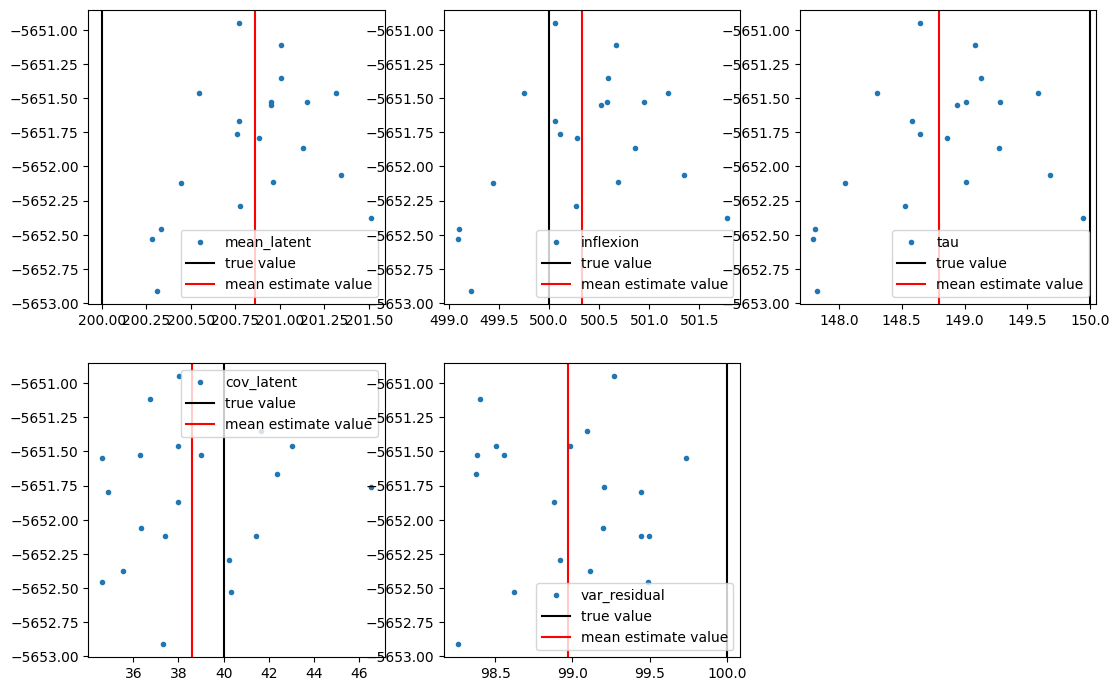

In [16]:
fig = sdgplt.figure()
params_names = myModel.params_names

pstar = myModel.hstack_params(p_star)
for i in range(len(pstar)):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.plot(
        jnp.array(multi_estim.last_theta)[:, i],
        multi_estim.likelihood,
        ".",
        label=params_names[i],
    )
    ax.axvline(x=pstar[i], color="k", label="true value")
    ax.axvline(
        x=jnp.array(multi_estim.last_theta)[:, i].mean(),
        color="r",
        label="mean estimate value",
    )
    ax.legend()

On veut calculer : 
$L_{marg}(\theta;Y) = \int f_\theta(Y|\varphi) f_\theta(\varphi) d \varphi$

Avec : $f_\theta(\varphi) = \prod_{i=1}^N \frac 1{\sqrt{2\pi\Gamma^2}}\times \exp\left(-\frac{(\varphi_i-\mu)^2}{\Gamma^2}\right)$ ($\varphi$ iid)

Et : $f_\theta(Y|\varphi) = \prod_{i=1}^N \prod_{j=1}^J \frac 1{\sqrt{2\pi\sigma^2}}\times \exp\left(\frac{-(Y_{i,j}-m(t_{i,j},\varphi_i))^2}{\sigma^2}\right)$ ($\epsilon$ iid)

Si $M_{i,j}^{-1} = 1+\exp\left(-\frac{t_{i,j}-\tau}\chi\right)$

$L_{marg}(\theta;Y) = \left(\frac 1{\sqrt{2\pi\sigma^2}}\right)^{N\times J} \left(\frac 1{\sqrt{2\pi\Gamma^2}}\right)^N \prod_{i=1}^N \prod_{j=1}^J 
    \int \exp\left(\frac{(Y_{i,j}-m(t_{i,j},\varphi_i))^2}{\sigma^2}\exp\left(-\frac{(\varphi_i-\mu)^2}{\Gamma^2}\right)\right)$

$L_{marg}(\theta;Y) \propto \prod_{i=1}^N \prod_{j=1}^J 
    \int \exp\left(-\frac{(Y_{i,j}-M_{i,j} \varphi_i))^2}{\sigma^2} - \frac{(\varphi_i-\mu)^2}{\Gamma^2}\right) d \varphi_i$


$$\log\left[\int_{-\infty}^\infty \exp\left(-(a-b x)^2 -(c-d x)^2\right)dx \right]= \frac 1 2 \log\left(\frac{\pi}{b^2+d^2}\right) - \frac{(bc-ad)^2}{b^2+d^2}$$



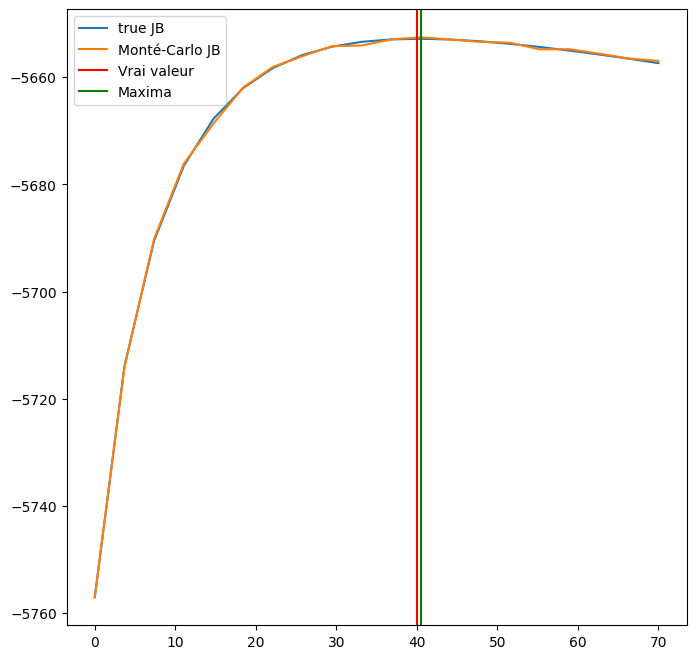

In [11]:
from sdg4varselect.models import log_likelihood_marginal
from sdg4varselect.models import log_gaussian_prior_cov


@jit
def log_likelihood_marginal_tom(Y, mem_obs_time, theta):
    params = myModel.parametrization.reals1d_to_params(theta)

    aij = 1 / (1 + jnp.exp(-(mem_obs_time - params.inflexion) / params.tau))
    out = 0
    for i in range(Y.shape[0]):
        out += log_gaussian_prior_cov(  # jnp.log(multi_normal_pdf(
            jnp.array([Y[i, :]]),
            mean=jnp.array(aij[i, :] * params.mean_latent[0]),
            cov=(
                aij[i, jnp.newaxis].T @ aij[i, jnp.newaxis] * params.cov_latent[0, 0]
                + params.var_residual * jnp.diag(jnp.ones(shape=aij.shape[1]))
            ),
        )

    return out[0]


def f(x):
    p_star = myModel.new_params(
        mean_latent={"asymptotic": 200},
        inflexion=500,
        tau=150,
        cov_latent=jnp.diag(jnp.array([x])),  # jnp.diag(jnp.array([40, 100])),
        var_residual=100,
    )
    theta = myModel.parametrization.params_to_reals1d(p_star)

    llm = log_likelihood_marginal(myModel, jrd.PRNGKey(int(x)), myobs, theta)

    hand = log_likelihood_marginal_tom(**myobs, theta=theta)

    return hand, llm


xx = jnp.linspace(0.001, 70, num=20)
y = jnp.array([f(x) for x in xx])

sdgplt.FIGSIZE = 8
fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
_ = ax.plot(xx, y, label=["true", "Monté-Carlo"])
ax.axvline(
    x=40,
    color="r",
    label="Vrai valeur",
)
ax.axvline(
    x=xx[y[:, 1].argmax()],
    color="g",
    label="Maxima",
)

ax.legend()